# Linear elasticity with full order and reduced order simulation

## Environment Setup

### Directory

In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))

### Standard Imports

In [2]:
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.visualization.generate_vtk import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est_t import *
import skrom.problem_classes.masterclass as master
from skrom.utils.visualization.color_palette import set_color_palette
from skrom.utils.visualization.generate_vtk import save_vtk_solution
# Register problem (runs @register_problem)
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def")

PETSc available: True


### Plot Properties

In [3]:
# # Define a custom color palette with 19 distinct colors
set_color_palette();
import sci_mplstyle_package

In [4]:
generate_data = True
visualize = True
run_svd = True
run_rom = True
rom_report = True

## Full Order Simulation

In [ ]:
# Conditional execution block for simulation data generation
if generate_data:
    
    sim = master.fom_simulation(num_snapshots=2**3)
    sim.run_simulation()

### Load Simulation data

In [6]:
# Load saved ROM_data (works even if 'generate=False')
rom_data = master.rom_simulation()

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\computational_mechanics\dynamic\linear\problem_beam_vibration_3d\ROM_data


### Generate Training Solution Dataset

In [7]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list =  np.asarray(rom_data.param_list)

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
LS = np.asarray(rom_data.fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = rom_data.train_mask, rom_data.test_mask

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
LS_train = LS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
LS_test = LS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap = len(LS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available


16


### Mean Subtraction

In [8]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
LS_train_mean = LS_train[:,0:1,:] #np.mean(LS_train,axis = 0)
# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
LS_train_ms = LS_train - LS_train_mean
#We will use SVD on the mean subtracted matrix data

### Vizualize Parameters

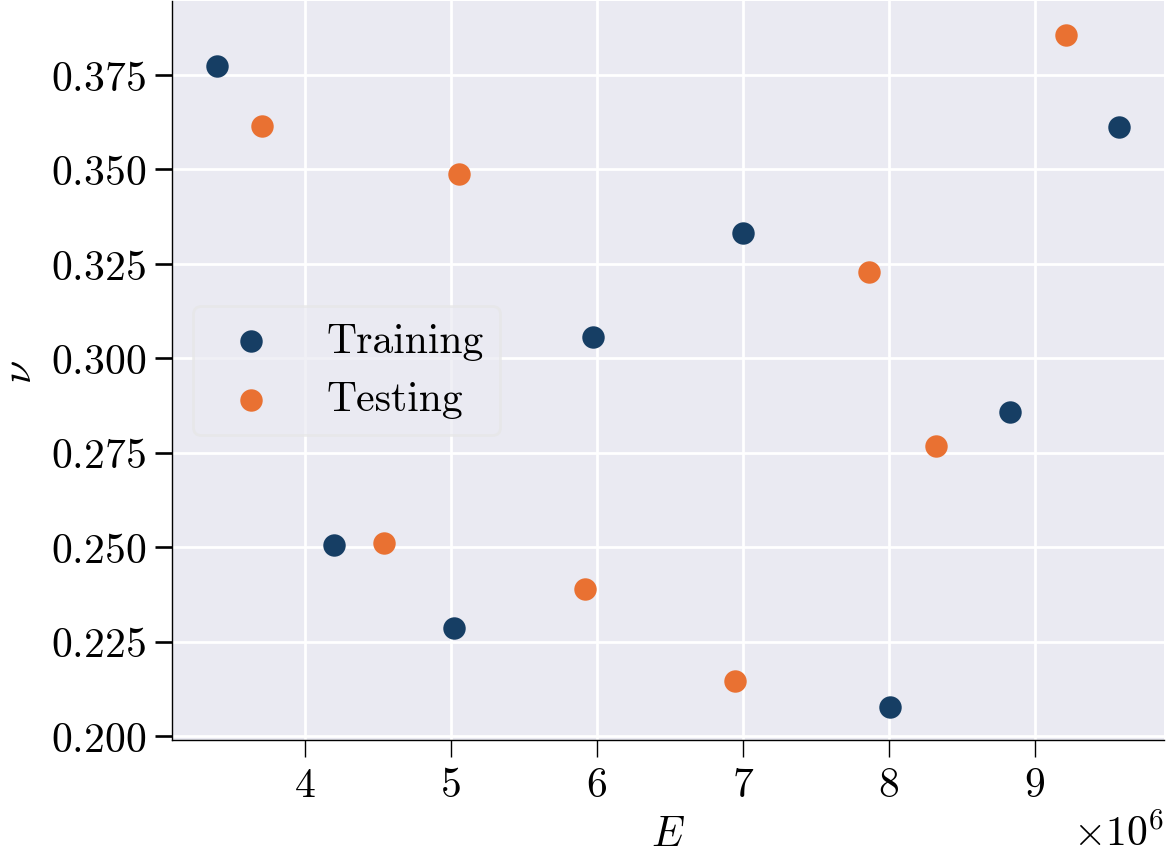

In [9]:
if visualize:
    
    # Visualize the parameter space distribution for training and testing data
    # Plot training parameter combinations (first 16 samples)
    # Extract first and second parameter columns for 2D visualization
    plt.scatter(param_list[:N_snap//2][:, 0],    # First parameter (μ) for training samples which are the k_params 
            param_list[:N_snap//2][:, 1],     # Second parameter (β) for training samples which are the q_params
            s=50,                      # Marker size
            c='#163e64',              # Dark blue color for training points
            label="Training")         # Legend label

    # Plot testing parameter combinations (samples 17 and beyond)
    plt.scatter(param_list[N_snap//2:][:, 0],    # First parameter (μ) for testing samples
            param_list[N_snap//2:][:, 1],     # Second parameter (β) for testing samples
            s=50,                      # Marker size (same as training)
            c='#e97132',              # Orange color for testing points
            label="Testing")          # Legend label

    # Set axis labels using LaTeX formatting for mathematical notation
    plt.xlabel("$E$")        # First parameter (often material property, conductivity, etc.) this is the k_params
    plt.ylabel("$\\nu$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

    # Add legend to distinguish between training and testing sets
    plt.legend()

    #See params and properties to see how these are used

### Performing SVD on solution snapshots

Number of modes selected: 91


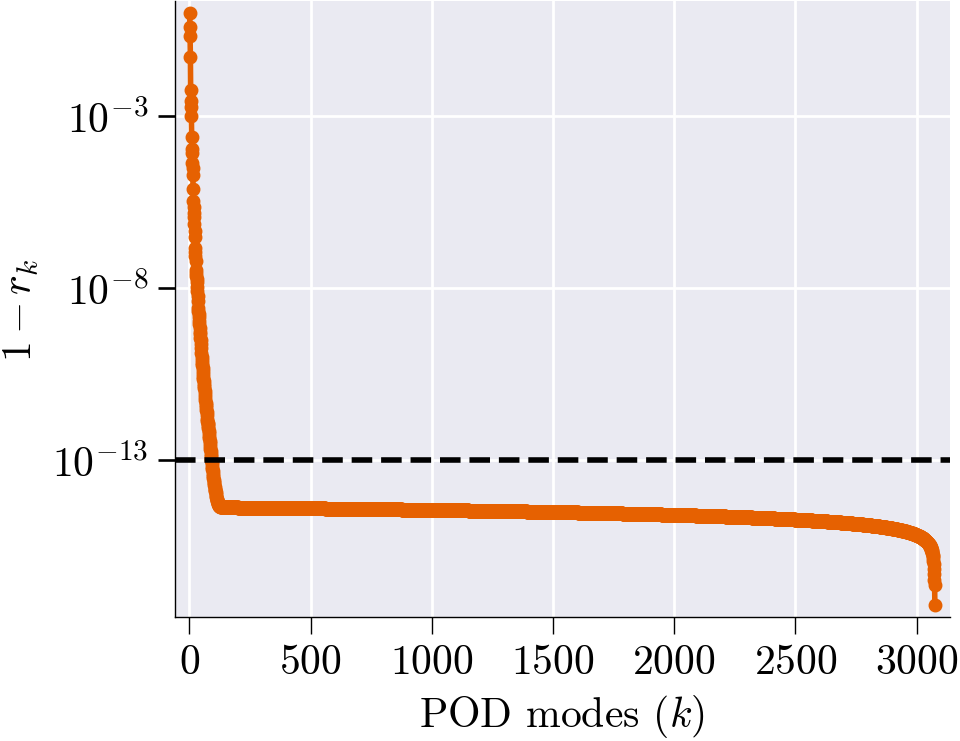

In [10]:
if run_svd:
    # Configure plot styling for POD analysis visualization
    plt.rcParams['lines.markersize'] = 6
    plt.rcParams['lines.linewidth'] = 2.0

    B = np.vstack([LS_train_ms[i] for i in range(LS_train_ms.shape[0])])  # (20000,3075)

    n_sel, U = svd_mode_selector(B, tolerance = 1e-13, modes=True)
    V_sel = U[:, :n_sel]
    plt.ylabel('$1-r_{k}$')
    plt.xlabel('POD modes ($k$)')

In [11]:
V_sel.shape

(3075, 91)

## ROM Simulation

In [12]:
if run_rom:
    # Initialize the reduced-order model (ROM) simulation with affine decomposition for speed-up
    #   V_sel : precomputed basis matrix (e.g., selected POD modes)
    rom = master.rom_simulation(V_sel = V_sel, train_ref= LS_train_mean[0])

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\computational_mechanics\dynamic\linear\problem_beam_vibration_3d\ROM_data


In [13]:
if run_rom:
    # Run the reduced-order model (ROM) simulation.
    # rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
    rom.run_rom_simulation();

Snap 1/8 params=[4.53994748e+06 2.50990632e-01]
Snap 2/8 params=[9.20986798e+06 3.85688274e-01]
Snap 3/8 params=[6.94608098e+06 2.14471310e-01]
Snap 4/8 params=[5.05374074e+06 3.48776962e-01]
Snap 5/8 params=[5.91848934e+06 2.39019787e-01]
Snap 6/8 params=[7.86551539e+06 3.22731896e-01]
Snap 7/8 params=[8.32460821e+06 2.76719400e-01]
Snap 8/8 params=[3.70937691e+06 3.61601650e-01]


In [14]:
if rom_report:
    #Assign values for the statistics
    LS_rom = np.asarray(rom.rom_solutions)
    ROM_speed_up = rom.speed_up
    ROM_speed_up=ROM_speed_up#[1:]
    ROM_relative_error = rom.rom_error

### ROM Solution vs Full order statistics

In [15]:
LS_test.shape[0]

8

ROM Accuracy Report

Global Errors:
L2 Error:                        4.7083e-02
Relative L2 Error:               1.2887e-04
L∞ Error:                        1.3136e-04
Relative L∞ Error:               1.0250e-04
RMSE:                            6.7125e-06
MAE:                             1.6629e-06

Statistical Fit:
R² Score:                        1.0000
Explained Variance:              1.0000

Error Distribution (absolute):
Median Abs Error:                7.4163e-08
95th Percentile Abs Error:       7.9260e-06

Time/Parameter-Dependent Errors:
Average Relative L2 over samples:        1.2735e-04
Max Relative L2 over samples:            1.9466e-03
Min Relative L2 over samples:            0.0000e+00
————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————


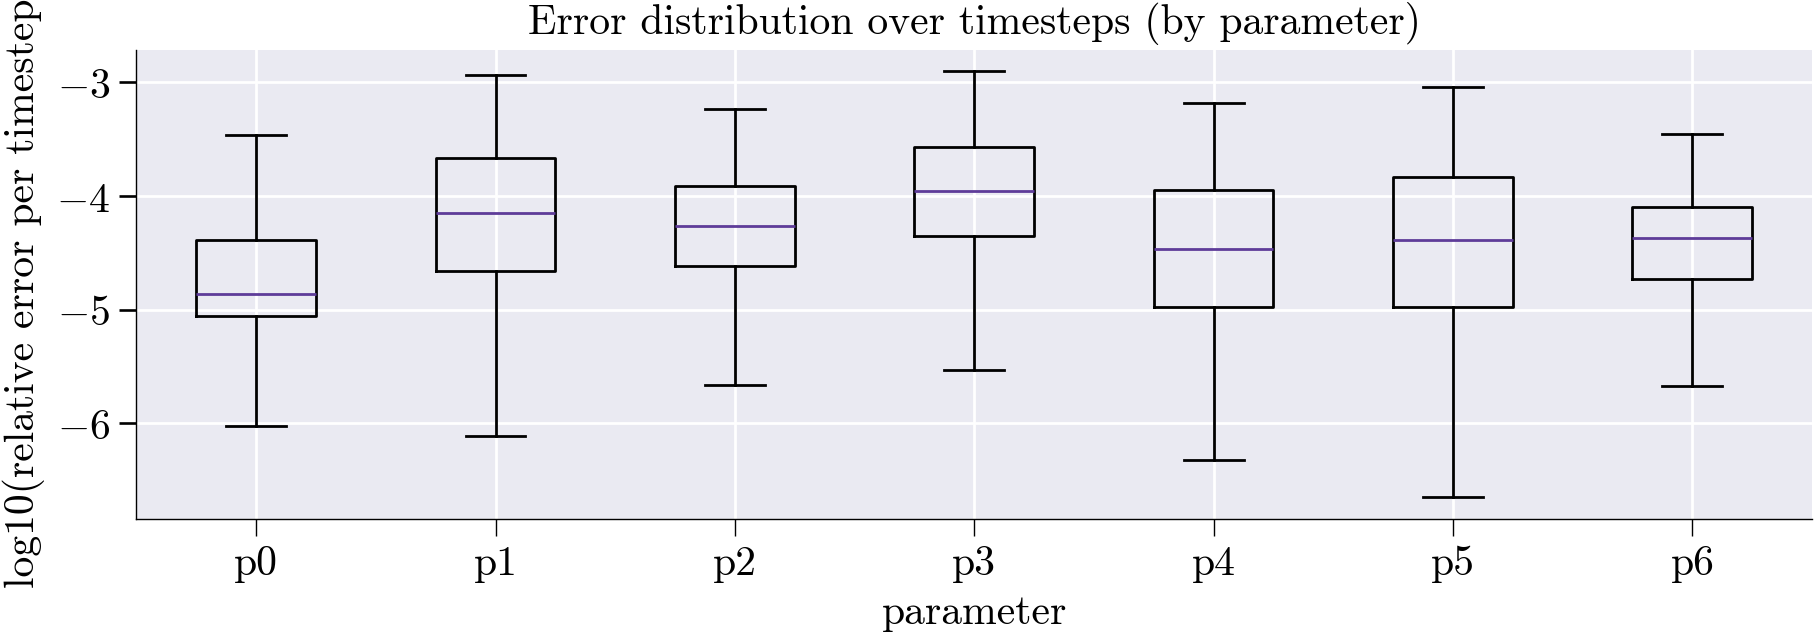

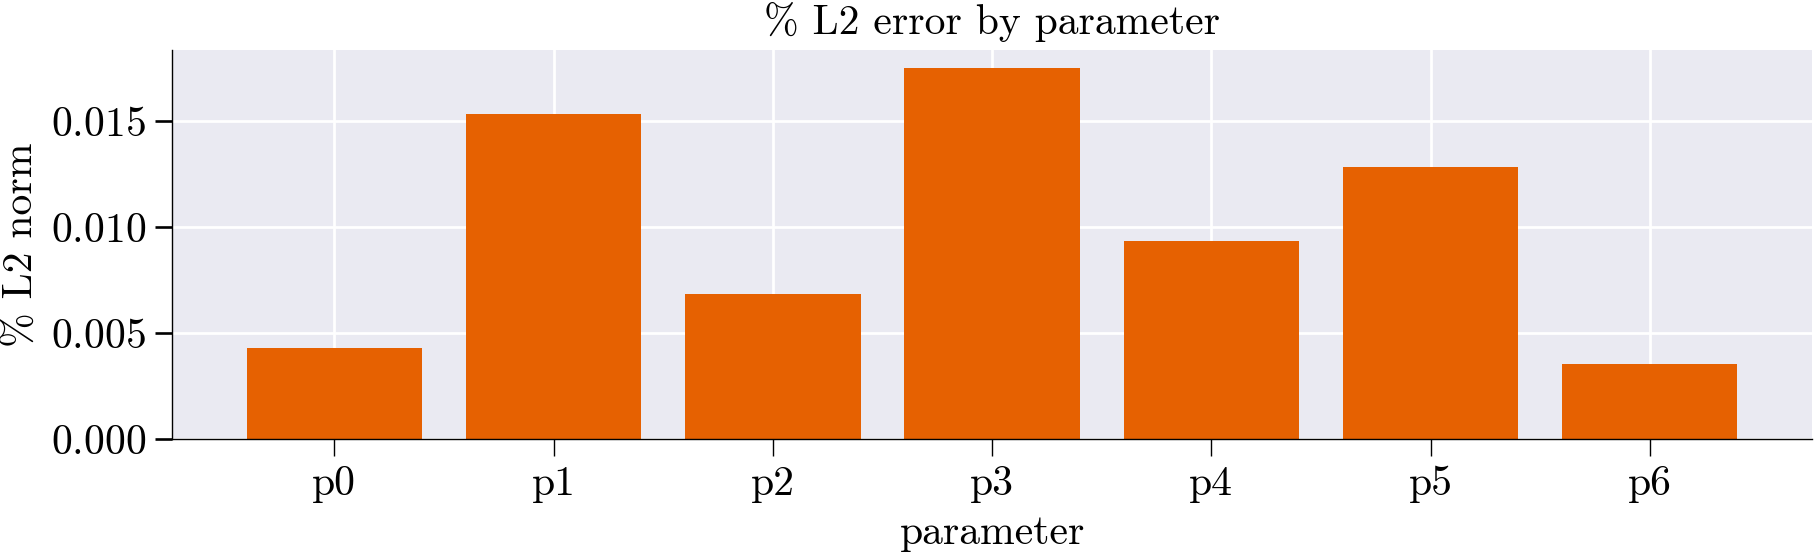

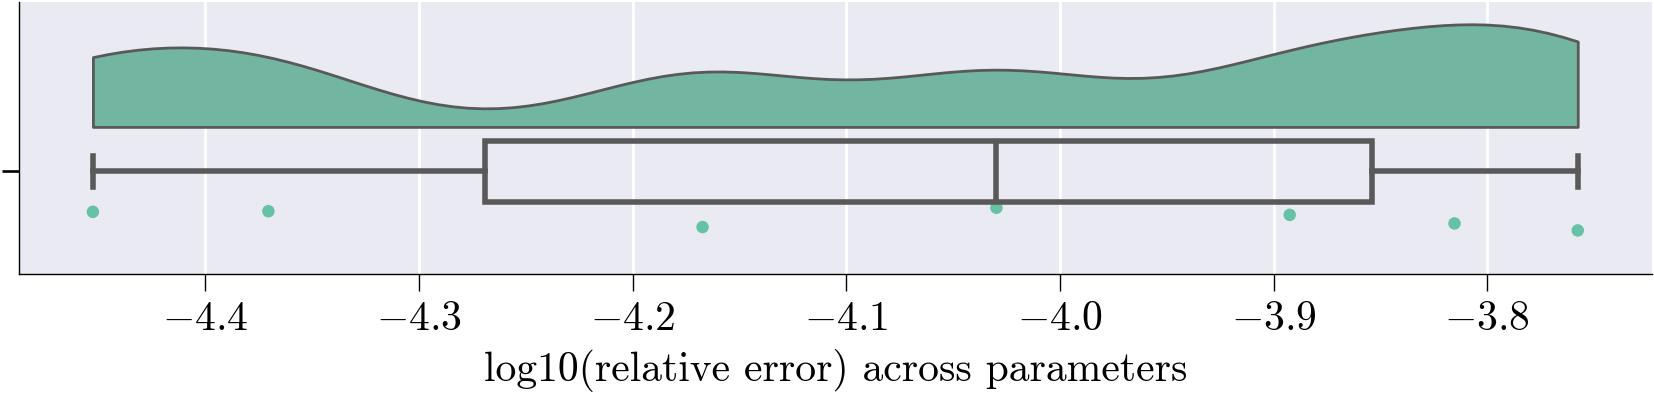

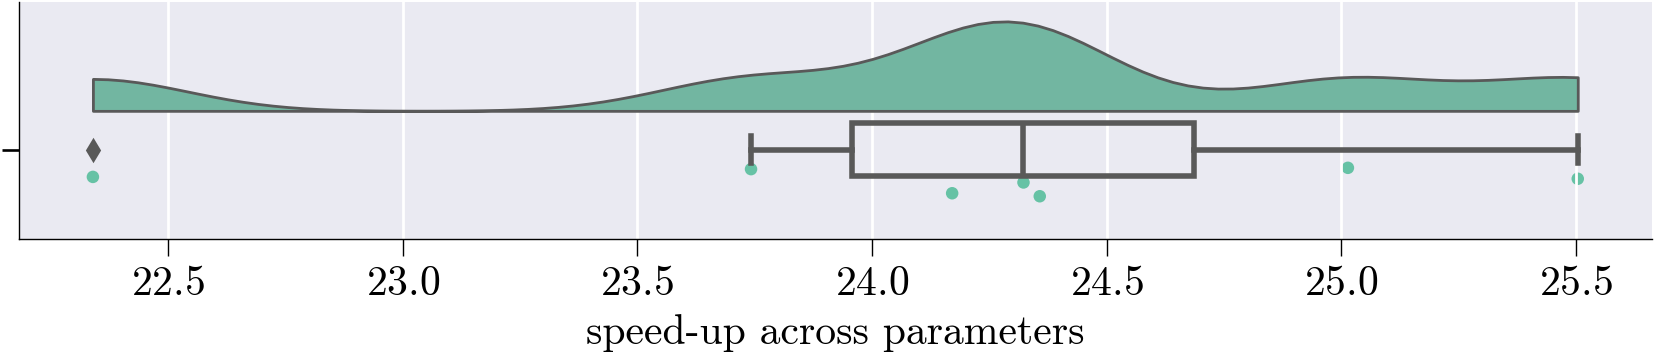

In [16]:
if rom_report:
    # --- ROM error analysis ---

    # Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
    matrix = compute_rom_error_metrics_flat(LS_test, LS_rom)
    # Produce a text-based report summarizing these hyper-ROM error metrics
    generate_rom_error_report(matrix)
    
    out = plot_rom_param_diagnostics_t(
        LS_test[1:],
        LS_rom[1:],
        l2_per_param=ROM_relative_error[1:],          # (p,)
        speedup_per_param=ROM_speed_up[1:], # (p,)
        param_labels=[f"p{i}" for i in range(LS_test.shape[0]-1)],
        use_raincloud=True,
    )

### Optional Visualization

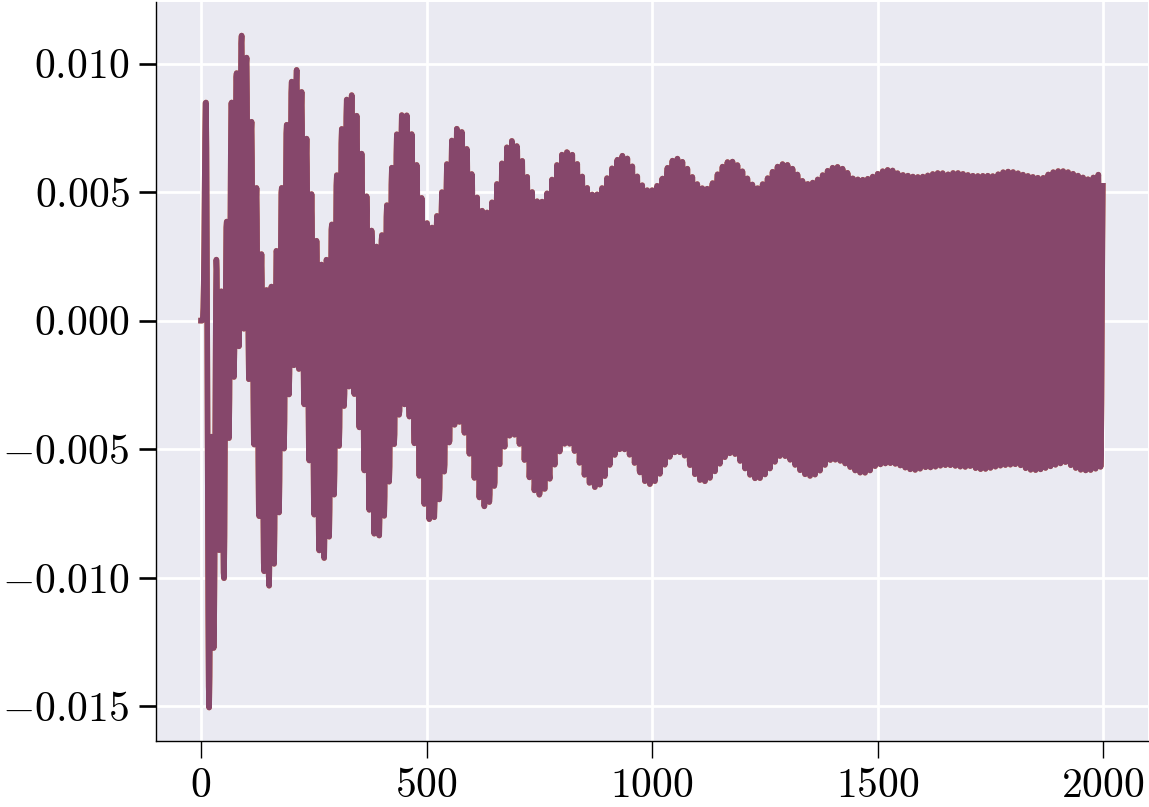

In [17]:
if visualize:
    plt.plot(LS_test[0][:,100])
    plt.plot(LS_rom[0][:,100],alpha=0.7)

## Visualize on paraview 

In [18]:
save_vtk_time_series(
    LS_rom[0].T, np.linspace(0,40,2000),
    rom_data.mesh, rom_data.basis,
    scale = 1e0,
    run_dir=Path("results/anim_rom"),
    prefix="beam"
)

In [19]:
save_vtk_time_series(
    LS_test[0].T, np.linspace(0,40,2000),
    rom_data.mesh, rom_data.basis,
    scale = 1e0,
    run_dir=Path("results/anim_fom"),
    prefix="beam"
)